# COGS 108 - EDA Checkpoint

Team list and credits:

- Alexis Menor: Conceptualization, Background research, Writing – original draft, Data curation
- Camdon Dreisbach: Methodology, Software, Data curation
- Ivan Li: Analysis, Visualization
- Joseph Tuazon: Project administration, Writing – review & editing,  Data curation
- Yuna Yeom: Analysis, Background research, Visualization

# Research Question

How does each players' position-normalized (OH (Outside Hitter), MB (Middle Blocker), OPP (Opposite Hitter), S (Setter), L (Libero), L/DS (Libero/Defensive Specialist)) cumulative workload-measured by actions (TotalAttacks, Digs , BlockAssists) per match impact hitting effiency (HitPct) in the later 4th or 5th sets compared to 1st set in NCAA Division 1 Matches in each respective season 2020-2024?

## Background and Prior Work

College athletes undergo demanding training and heavy competition schedules while simultaneously managing academic responsibilities. As a result, fatigue has emerged as a critical factor influencing athletic performance, recovery, and mental health. In sports such as volleyball, where matches are structured into sequential sets, fatigue may accumulate as competition progresses, potentially leading to declines in performance during later sets of a match. Prior research suggests that volleyball players that experience excessive physical and cognitive workload can reduce performance quality, including a decrease in visual perception, concentration, and reaction time <a id="cite_ref_1"></a><sup><a href="#cite_note_1">1</a></sup>.

Due to volleyball’s varying gameplay, examining fatigue can vary across positions because of the sport-specific demands. Players can engage in hitting, setting, defense, and blocking, which differ in their actions like jumping, lateral movement, reaction speed, and quick directional changes. Because of the specific position that players are in, their exhaustion can differ with the varying demands they have to meet. Previous research suggests that fatigue can be position-specific and can localize in different areas of the body <a id="cite_ref_2"></a><sup><a href="#cite_note_2">2</a></sup>. Hitters and blockers frequently jump in comparison to setters and defensive specialists, so differences in physical fatigue makes sense. Thus, it is important to consider how different positions need to recover during and after a strenuous game. Additionally, the change from pre-season preparation to in-season competition, then to the off-season, can impact an athlete’s recovery and performance <a id="cite_ref_3"></a><sup><a href="#cite_note_3">3</a></sup>. The shift from pre-season, where training is moderate and games are seldom, to in-season, where training increases and games are often, can also be a relevant factor to consider in a player's performance. 

Existing literature primarily focuses on physiological measures of fatigue or subjective survey-based assessments collected during training and competition. However, there is comparatively limited research examining how fatigue translates into measurable statistical performance changes during competitive play, particularly at the collegiate level. 

This project aims to address these gaps by analyzing how fatigue relates to in-game statistical performance across game sets and positions. By comparing early-set performance to late-set performance, we can provide quantitative insight into how cumulative intensity of playing-time affects gameplay outcomes. 

1. <p id="cite_note_1">
  <a href="#cite_ref_1">^</a>
Yu, Y., Zhang, L., Cheng, M.-Y., Liang, Z., Zhang, M., & Qi, F. (2025). <i>The effects of different fatigue types on action anticipation and physical performance in high-level volleyball players </i>. Journal of Sports Sciences, 43(4), 323–335. https://doi.org/10.1080/02640414.2025.2456399 </p>

2. <p id="cite_note_2">
  <a href="#cite_ref_2">^</a> 
Ungureanu, A. N., Lupo, C., Boccia, G., & Brustio, P. R. (2021). <i>Internal Training Load Affects Day-After-Pretraining Perceived Fatigue in Female Volleyball Players. International Journal of Sports Physiology and Performance </i>, 16(12), 1844-1850. Retrieved Feb 5, 2026, from https://doi.org/10.1123/ijspp.2020-0829 
</p>

3. <p id="cite_note_3">
  <a href="#cite_ref_3">^</a>
Rebelo, A., Pereira, J.R., Cunha, P. et al. <i>Training stress, neuromuscular fatigue and well-being in volleyball: a systematic review</i>. BMC Sports Sci Med Rehabil 16, 17 (2024). https://doi.org/10.1186/s13102-024-00807-7 
</p>


# Hypothesis


High-intensity workload (TotalAttacks, Digs, BlockAssists, etc) will negatively correlate with HitPct in late-match sets (4 and 5), characterized by a downward shift in mean efficiency. We choose this method as it relies on cumulative physiological load and is measured by readily available data. We expect to see positions that require more stamina setter and outside hitter to be most affected by later sets in terms of hiting efficiency.

## Data

### Data overview

We have collected data from a source that has condensed match statistics of NCAA D1 volleyball games for men and women during the 2020-2024 seasons.  This dataset contains information about Total Attacks, Hitting Percentage (Hit Pct), Assists, Digs, Aces, Receiving Errors (RErr), Blocking Errors (BErr), Service Errors (SErr), Block Assists, and Block Solos. 

- Dataset #1
  - Dataset Name: D1 MVB & WVB playermatch stats 2020-2024
  - Link to the dataset: https://github.com/JeffreyRStevens/ncaavolleyballr/tree/main/data-csv
  - Number of observations: 254655
  - Number of variables: 26
  - Description of the variables most relevant to this project
  -  This dataset contains information about each player and their Total Attacks, Hitting Percentage (Hit Pct), Aces, Assists, Digs, Block Assists, Errors, and Block Solos. They also include how many sets, what day they played on, which season they were i

In [65]:
#imports:
import sys
sys.path.append('./modules')
import get_data
import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [66]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
#google drive link if fails: https://drive.google.com/drive/folders/1qfIbuHxvh0eO1JPVdmo-UK0i6wbjpWAr?usp=sharing

datafiles = [
    # dataset #1: 
    # Women's Volleyball Playermatch
    { 'url': 'https://drive.google.com/uc?export=download&id=1uDmxjZ3oSQzH_zpCjQ1cD5FaQyhEFsDS', 'filename':'wvb_playermatch_div1_2020.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1g-SCURPoCvg9sbymeITHFOKxwpVtLhWu', 'filename':'wvb_playermatch_div1_2021.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1cjoRrEDBchevgy4BB_djxbD-ZVDmFdkv', 'filename':'wvb_playermatch_div1_2022.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=19GhygI-8G-n6byftb7x_grdzKRp3z0A8', 'filename':'wvb_playermatch_div1_2023.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1bhp_-3JDhkbIhZZSusecxctEPwrIRkTn', 'filename':'wvb_playermatch_div1_2024.txt'},
    # Men's Volleyball Playermatch
    { 'url': 'https://drive.google.com/uc?export=download&id=1DlK2JG8K-uTeIOvQjErXVT8piQqlXFBA', 'filename':'mvb_playermatch_div1_2020.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1lRM0zdLMs3EXzbSxbNN7BofwHj6eoaWr', 'filename':'mvb_playermatch_div1_2021.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1PXhG51WSSrbt-EYr2SerzszAbZnOfX6R', 'filename':'mvb_playermatch_div1_2022.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1-DcXeMYoA4qujmZtMXqJqNXaEwH-OcQR', 'filename':'mvb_playermatch_div1_2023.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1bGHDYDMZr74-MF3wncij9W5Xt4-Cu0tz', 'filename':'mvb_playermatch_div1_2024.txt'},
    # dataset #2:
    #  Men's Play-by-Play (PBP)
    { 'url': 'https://drive.google.com/uc?export=download&id=1YxKmZS3JiQFaC3A8Tfy9i6GwIJeY37vo', 'filename':'mvb_pbp_div1_2020.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1XkXwrpW1DNEen8yvr3TmL8HyUMsusvER', 'filename':'mvb_pbp_div1_2021.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1zakp7XYwZ1PbgoIGc7oyx6bmyxyBFfq2', 'filename':'mvb_pbp_div1_2022.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1l8Kf6dvqApO9XAkAOU6OvYtm11ZnBNtL', 'filename':'mvb_pbp_div1_2023.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=111MGjvDaPlIn47c7KW_Y7-e-yYVzbVV9', 'filename':'mvb_pbp_div1_2024.txt'},
    # Women's Play-by-Play (PBP) NOTE CURRENTLY BROKEN CAN'T BYPASS ANTIVIRUS
    { 'url': 'https://drive.google.com/uc?export=download&id=1rgBHzDhKXlImBEBUx4ioBObXZon0eMOh', 'filename':'wvb_pbp_div1_2020.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1crNJyElUt99fbwcjMfByiSYwMESNcREa', 'filename':'wvb_pbp_div1_2021.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1WUKw5wHSGk4YtOdCYoy_ekAb7l1EVHT7', 'filename':'wvb_pbp_div1_2022.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=18WBwfktZljA8jk7uExwdZgBMTFdui_8k', 'filename':'wvb_pbp_div1_2023.txt'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1ViYGjJs_UypLq8ujPAgDhw_mqenQfOQw', 'filename':'wvb_pbp_div1_2024.txt'}
]
get_data.get_raw(datafiles, destination_directory='data/00-raw/')

Overall Download Progress: 100%|██████████| 20/20 [00:00<00:00, 18953.02it/s]

Skipping wvb_playermatch_div1_2020.txt - already exists.
Skipping wvb_playermatch_div1_2021.txt - already exists.
Skipping wvb_playermatch_div1_2022.txt - already exists.
Skipping wvb_playermatch_div1_2023.txt - already exists.
Skipping wvb_playermatch_div1_2024.txt - already exists.
Skipping mvb_playermatch_div1_2020.txt - already exists.
Skipping mvb_playermatch_div1_2021.txt - already exists.
Skipping mvb_playermatch_div1_2022.txt - already exists.
Skipping mvb_playermatch_div1_2023.txt - already exists.
Skipping mvb_playermatch_div1_2024.txt - already exists.
Skipping mvb_pbp_div1_2020.txt - already exists.
Skipping mvb_pbp_div1_2021.txt - already exists.
Skipping mvb_pbp_div1_2022.txt - already exists.
Skipping mvb_pbp_div1_2023.txt - already exists.
Skipping mvb_pbp_div1_2024.txt - already exists.
Skipping wvb_pbp_div1_2020.txt - already exists.
Skipping wvb_pbp_div1_2021.txt - already exists.
Skipping wvb_pbp_div1_2022.txt - already exists.
Skipping wvb_pbp_div1_2023.txt - alrea

### Dataset #1 Women's/Men's Volleyball Player Statistics, D1 2020-2024 

Instructions:

This dataset details statistics for every D1 women's volleyball player within the NCAA from 2020-2024. Variables to consider are:

- Team: team that the player is associated with
- Season: which year (2020, 2021, 2022, 2023, 2024) the statistics are from
- Date: game day
- Conference: respective conference that the team is in
- Opponent_Team: who that team/player was playing against
- Opponent_Conference: the respective conference that the opponent is in
- Location: whether that game was at their home court or at their opponent's court
- Player: name of the player
- P: points that the player made
- S: sets played in
- Kills: number of offensive attacks made
- Errors: any mistake made resulting in a point for the other team
- TotalAttacks: total attempts for offensive attacks
- HitPct: kills minus errors divided by total attempts
- Assists: number of sets that resulted in a kill 
- Aces: service points
- SErr: service errors
- Digs: number of times receiving the ball from the opponent after an attack is attempted
- RErr: receive error
- BlockSolos: one player making a block of an opponent's attempt to attack
- BlockAssists: two players making a block of an opponent's attempt to attack
- BErr: blocking error
- ***TB (Women's Only)***: Total blocks (Note: This variable is unique to the Women's dataset; for the Men's dataset, this must be calculated as BlockSolos + BlockAssists).
- PTS: total points a player has scored 
- BHE: ball handling error (technical foul of a player mishandling the ball i.e. 'double' or 'lift'

We will identify the key variables to focus on to analyze fatigue and player performance. Most likely points made or assisted through Kills, Aces, Assists, TB will be compared to the error variables. Some potential concerns with this data set might include unequal playing time, which may affect what truly contributes to low stats or high stats. Additionally, we must think about the context of these games, such as opponent strength and the effect of home vs away games. 



In [68]:
data_dir = 'data/00-raw/'
year = [2020, 2021, 2022, 2023, 2024]
mvb_playermatch_df = []
wvb_playermatch_df = []
for y in year:
    f_name_mvb = f'mvb_playermatch_div1_{y}.txt'
    f_path_mvb = f"{data_dir}{f_name_mvb}"
    temp_df_mvb = pd.read_csv(f_path_mvb)

    f_name_wvb = f'wvb_playermatch_div1_{y}.txt'
    f_path_wvb = f"{data_dir}{f_name_wvb}"
    temp_df_wvb = pd.read_csv(f_path_wvb)

    mvb_playermatch_df.append(temp_df_mvb)
    wvb_playermatch_df.append(temp_df_wvb)

#combine all years
mvb_playermatch_df = pd.concat(mvb_playermatch_df, ignore_index = True)
wvb_playermatch_df = pd.concat(wvb_playermatch_df, ignore_index = True)

#before cleaning
rows_before_mvb = len(mvb_playermatch_df)
rows_before_wvb = len(wvb_playermatch_df)

#data cleaning

#drop duplicate columns
wvb_playermatch_df = wvb_playermatch_df.drop(columns=['team']) 
mvb_playermatch_df = mvb_playermatch_df.drop(columns=['team'])

#drop all numerical nan columns
num_cols_mvb = mvb_playermatch_df.select_dtypes(include=['number']).columns
mvb_playermatch_df = mvb_playermatch_df.dropna(subset=num_cols_mvb)

num_cols_wvb = wvb_playermatch_df.select_dtypes(include=['number']).columns
wvb_playermatch_df = wvb_playermatch_df.dropna(subset=num_cols_wvb)

#drop nan positions
mvb_playermatch_df = mvb_playermatch_df.dropna(subset=['P'])
wvb_playermatch_df = wvb_playermatch_df.dropna(subset=['P'])

In [69]:
#WVB after cleaning
print("Number of observations before cleaning", rows_before_wvb)
print("Number of observations after cleaning:", wvb_playermatch_df.shape[0])
print("Number of variables:", wvb_playermatch_df.shape[1])
print(f"Rows dropped: {rows_before_wvb - len(mvb_playermatch_df)}")
print("\nVariable names:")
print(wvb_playermatch_df.columns)

wvb_playermatch_df.head()

Number of observations before cleaning 254668
Number of observations after cleaning: 0
Number of variables: 28
Rows dropped: 217098

Variable names:
Index(['Season', 'Date', 'Team', 'Conference', 'Opponent Team',
       'Opponent Conference', 'Location', 'Number', 'Player', 'P', 'S', 'MS',
       'Kills', 'Errors', 'TotalAttacks', 'HitPct', 'Assists', 'Aces', 'SErr',
       'Digs', 'RErr', 'BlockSolos', 'BlockAssists', 'BErr', 'TB', 'PTS',
       'BHE', 'RetAtt'],
      dtype='str')


,Season,Date,Team,Conference,Opponent Team,Opponent Conference,Location,Number,Player,P,...,SErr,Digs,RErr,BlockSolos,BlockAssists,BErr,TB,PTS,BHE,RetAtt


In [70]:
#MVB after cleaning
print("Number of observations before cleaning", rows_before_mvb)
print("Number of observations after cleaning:", mvb_playermatch_df.shape[0])
print("Number of variables:", mvb_playermatch_df.shape[1])
print(f"Rows dropped: {rows_before_mvb - len(mvb_playermatch_df)}")
print("\nVariable names:")
print(mvb_playermatch_df.columns)

mvb_playermatch_df.head()

Number of observations before cleaning 39050
Number of observations after cleaning: 37570
Number of variables: 26
Rows dropped: 1480

Variable names:
Index(['Season', 'Date', 'Team', 'Conference', 'Opponent Team',
       'Opponent Conference', 'Location', 'Number', 'Player', 'P', 'S', 'MS',
       'Kills', 'Errors', 'TotalAttacks', 'HitPct', 'Assists', 'Aces', 'SErr',
       'Digs', 'RErr', 'BlockSolos', 'BlockAssists', 'BErr', 'PTS', 'BHE'],
      dtype='str')


,Season,Date,Team,Conference,Opponent Team,Opponent Conference,Location,Number,Player,P,...,Assists,Aces,SErr,Digs,RErr,BlockSolos,BlockAssists,BErr,PTS,BHE
0,2021-2022,2021-03-20,CSUN,Big West,UC Irvine,Big West,Away,2,Johnny Anselmo,L,...,0,0,0,0,2,0,0,0,0.0,0
1,2021-2022,2021-03-20,CSUN,Big West,UC Irvine,Big West,Away,14,Cole Chea,MB,...,0,0,3,1,0,0,2,0,8.0,0
2,2021-2022,2021-03-20,CSUN,Big West,UC Irvine,Big West,Away,6,Ryan DeWeese,OPP,...,0,0,0,0,0,0,0,0,0.0,0
3,2021-2022,2021-03-20,CSUN,Big West,UC Irvine,Big West,Away,7,Kyle Hobus,OH,...,3,1,7,7,0,0,4,0,10.0,0
4,2021-2022,2021-03-20,CSUN,Big West,UC Irvine,Big West,Away,5,Kyle Merchen,S,...,35,1,3,7,0,0,0,0,1.0,0


In [71]:
#output processed data
out_path = 'data/02-processed/wvb_playermatch_combined.csv'
wvb_playermatch_df.to_csv(out_path, index = False)
out_path = 'data/02-processed/mvb_playermatch_combined.csv'
mvb_playermatch_df.to_csv(out_path, index = False)

### Dataset #2 Women/Men's Volleyball Play by Play Statistics, D1 2020-2024

Instructions:

This dataset provides a chronological log of every tactical event that occurred during NCAA D1 Men's Volleyball matches from 2020 to 2024. Unlike summarized box scores, this granular data captures the flow of the game, allowing for an analysis of momentum, rotation-specific performance, and player workload over the duration of a match. Variables to consider are:

- Date: The calendar date the match was played.
- Set: The specific set number within the match (1 through 5).
- Away_Team: The visiting team.
- Home_Team: The hosting team.
- Score: The live point tally at the time of the event (formatted as "Away-Home").
- Team: The specific team performing the current action.
- Event: The categorical action taking place (e.g., Serve, Reception, Set, Attack, Kill, Block, etc.).
- Player: The name of the individual player responsible for the event.
- Description: A text-based summary of the play (e.g., "Dylan Zhai serves" or "Attack by Daniel Wetter").

We will utilize this dataset to map out player activity over time to identify signs of fatigue. By tracking the frequency and success rate of "Events" (specifically Attacks and Kills) as the "Set" count increases or as the "Score" reaches high-leverage situations, we can measure performance decay.

In [72]:
#NOTE if you are running this their is a google drive issue when pulling the dataset pbp since it is large
data_dir = 'data/00-raw/'
years = [2020, 2021, 2022, 2023, 2024]
mvb_pbp_df = []
wvb_pbp_df = []
for y in years:
    f_name_mvb = f'mvb_pbp_div1_{y}.txt'
    f_path_mvb = f"{data_dir}{f_name_mvb}"
    temp_df_mvb = pd.read_csv(f_path_mvb)

    f_name_wvb = f'wvb_pbp_div1_{y}.txt'
    f_path_wvb = f"{data_dir}{f_name_wvb}"
    temp_df_wvb = pd.read_csv(f_path_wvb)

    mvb_pbp_df.append(temp_df_mvb)
    wvb_pbp_df.append(temp_df_wvb)

#combine all years
mvb_pbp_df = pd.concat(mvb_pbp_df, ignore_index=True)
wvb_pbp_df = pd.concat(wvb_pbp_df, ignore_index=True)

#before cleaning
rows_before_mvb = len(mvb_pbp_df)
rows_before_wvb = len(wvb_pbp_df)

#data cleaning

# removes the "+", "", "+" placeholders (Garabage Data)
mvb_pbp_df = mvb_pbp_df[mvb_pbp_df['event'] != '+'].dropna(subset=['player', 'event'])
wvb_pbp_df = wvb_pbp_df[wvb_pbp_df['event'] != '+'].dropna(subset=['player', 'event'])

#drop all numerical nan columns
num_cols_mvb = mvb_pbp_df.select_dtypes(include=['number']).columns
mvb_pbp_df = mvb_pbp_df.dropna(subset=num_cols_mvb)

num_cols_wvb = wvb_pbp_df.select_dtypes(include=['number']).columns
wvb_pbp_df = wvb_pbp_df.dropna(subset=num_cols_wvb)

In [73]:
#placer holder print for now
print(f"Men's PBP: {len(mvb_pbp_df)} rows (Removed {rows_before_mvb - len(mvb_pbp_df)} junk rows)")
print(f"Women's PBP: {len(wvb_pbp_df)} rows (Removed {rows_before_wvb - len(wvb_pbp_df)} junk rows)")

Men's PBP: 3175291 rows (Removed 30264 junk rows)
Women's PBP: 24184314 rows (Removed 136164 junk rows)


In [74]:
#output processed data
out_path = 'data/02-processed/wvb_pbp_combined.csv'
wvb_pbp_df.to_csv(out_path, index = False)
out_path = 'data/02-processed/mvb_pbp_combined.csv'
mvb_pbp_df.to_csv(out_path, index = False)

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [75]:
data_dir = 'data/02-processed/'
df_mvb_playermatch= pd.read_csv(data_dir + 'mvb_playermatch_combined.csv')
df_wvb_playermatch= pd.read_csv(data_dir + 'wvb_playermatch_combined.csv')

df_mvb_playermatch['Gender'] = 'Men'
df_wvb_playermatch['Gender'] = 'Women'

combined_df = pd.concat([df_mvb_playermatch, df_wvb_playermatch], ignore_index=True)

print(f"Combined Shape: {combined_df.shape}")
print(combined_df['Gender'].value_counts())
combined_df.columns

Combined Shape: (37570, 29)
Gender
Men    37570
Name: count, dtype: int64


Index(['Season', 'Date', 'Team', 'Conference', 'Opponent Team',
       'Opponent Conference', 'Location', 'Number', 'Player', 'P', 'S', 'MS',
       'Kills', 'Errors', 'TotalAttacks', 'HitPct', 'Assists', 'Aces', 'SErr',
       'Digs', 'RErr', 'BlockSolos', 'BlockAssists', 'BErr', 'PTS', 'BHE',
       'Gender', 'TB', 'RetAtt'],
      dtype='str')

In [76]:
combined_df["HitPct"] = pd.to_numeric(combined_df["HitPct"], errors="coerce")
combined_df = combined_df.dropna(subset=["HitPct"])

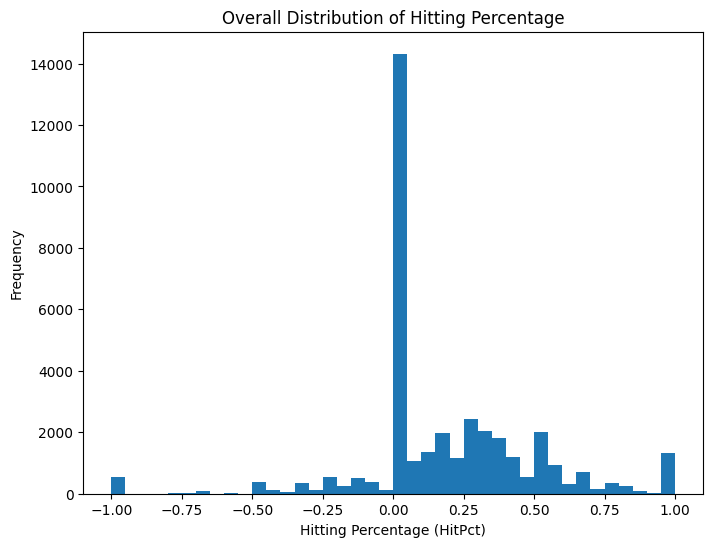

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.hist(combined_df["HitPct"], bins=40)
plt.xlabel("Hitting Percentage (HitPct)")
plt.ylabel("Frequency")
plt.title("Overall Distribution of Hitting Percentage")
plt.show()

In [78]:
mean_val = combined_df["HitPct"].mean()
median_val = combined_df["HitPct"].median()

print("Mean:", mean_val)
print("Median:", median_val)

Mean: 0.17399483630556295
Median: 0.1


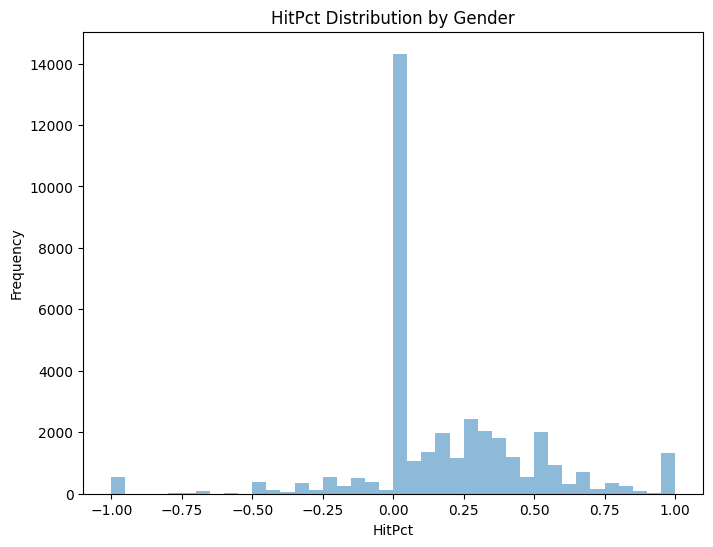

In [79]:
men = combined_df[combined_df["Gender"] == "Men"]
women = combined_df[combined_df["Gender"] == "Women"]

plt.figure(figsize=(8,6))
plt.hist(men["HitPct"], bins=40, alpha=0.5)
plt.hist(women["HitPct"], bins=40, alpha=0.5)

plt.xlabel("HitPct")
plt.ylabel("Frequency")
plt.title("HitPct Distribution by Gender")
plt.show()

In [80]:
combined_df[combined_df["HitPct"] == 0]["TotalAttacks"].describe()

count     14040
unique       44
top           0
freq      10097
Name: TotalAttacks, dtype: int64

In [81]:
combined_df[combined_df["HitPct"] == 0]["P"].value_counts()

P
L       4355
OH      3720
S       2642
MB      1165
L/DS     857
OPP      808
DB       443
RS        36
MH        14
Name: count, dtype: int64

In [82]:
analysis_df = combined_df[combined_df["TotalAttacks"] > 0]

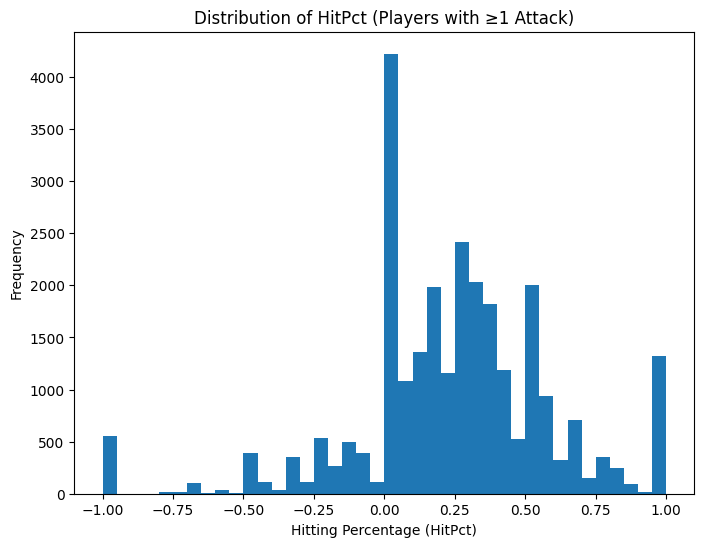

In [83]:
plt.figure(figsize=(8,6))
plt.hist(analysis_df["HitPct"], bins=40)
plt.xlabel("Hitting Percentage (HitPct)")
plt.ylabel("Frequency")
plt.title("Distribution of HitPct (Players with ≥1 Attack)")
plt.show()

In [84]:
analysis_df = combined_df[combined_df["TotalAttacks"] > 0]
men = analysis_df[analysis_df["Gender"] == "Men"]
women = analysis_df[analysis_df["Gender"] == "Women"]

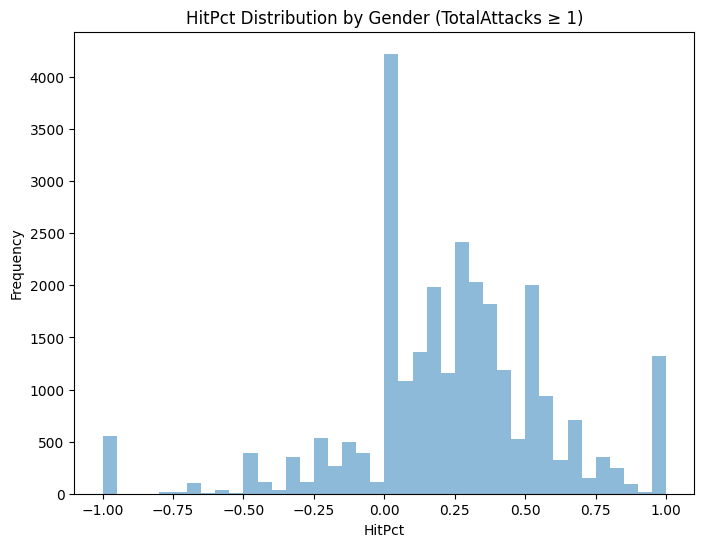

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.hist(men["HitPct"], bins=40, alpha=0.5)
plt.hist(women["HitPct"], bins=40, alpha=0.5)

plt.xlabel("HitPct")
plt.ylabel("Frequency")
plt.title("HitPct Distribution by Gender (TotalAttacks ≥ 1)")
plt.show()

In [86]:
analysis_df.groupby("Gender")["HitPct"].mean()
analysis_df.groupby("Gender")["HitPct"].median()

Gender
Men    0.25
Name: HitPct, dtype: float64

d:\Users\Luna\Desktop\COGS 108\Group035_WI26\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


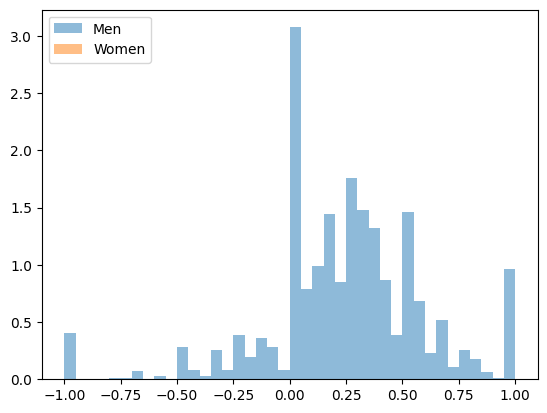

In [87]:
plt.hist(men["HitPct"].dropna(), bins=40, alpha=0.5, density=True, label='Men')
plt.hist(women["HitPct"].dropna(), bins=40, alpha=0.5, density=True, label='Women')
plt.legend()
plt.show()

In [88]:
analysis_df = combined_df[combined_df["TotalAttacks"] > 0].copy()
analysis_df["P"] = analysis_df["P"].str.upper()

analysis_df["P"] = analysis_df["P"].replace({
    "SETTER": "S",
    "MH": "MB",
    "MIDDLEBLOCKER": "MB",
    "OUTSIDEHITTER": "OH",
    "RS": "OPP",
    "DB": "DS/L",
    "DS": "DS/L",
    "DS-L": "DS/L",
    "L/DS": "DS/L",
    "L": "DS/L"
})

<Figure size 1000x600 with 0 Axes>

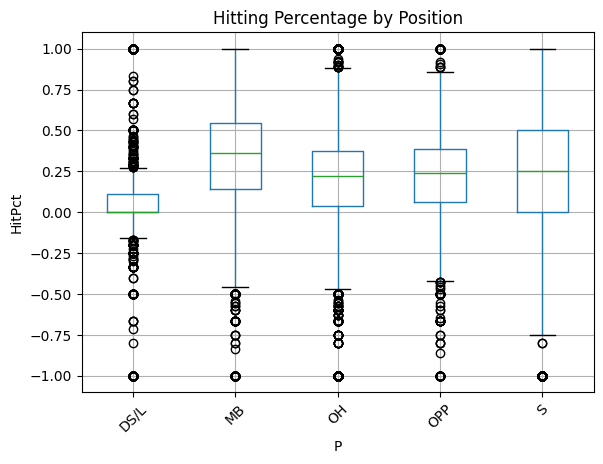

In [89]:
plt.figure(figsize=(10,6))
analysis_df.boxplot(column="HitPct", by="P", rot=45)
plt.title("Hitting Percentage by Position")
plt.suptitle("")
plt.ylabel("HitPct")
plt.show()

<Figure size 1000x600 with 0 Axes>

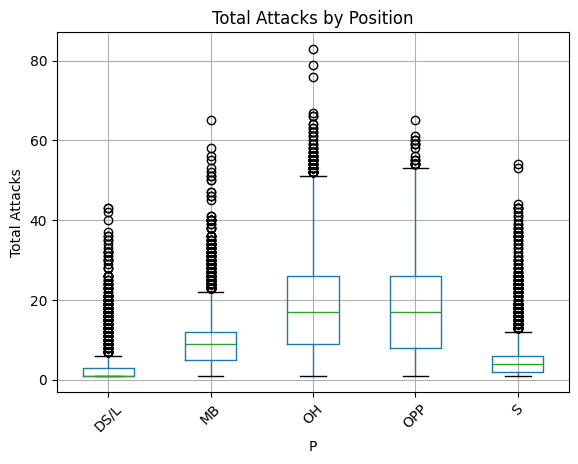

In [90]:
plt.figure(figsize=(10,6))
analysis_df.boxplot(column="TotalAttacks", by="P", rot=45)
plt.title("Total Attacks by Position")
plt.suptitle("")
plt.ylabel("Total Attacks")
plt.show()

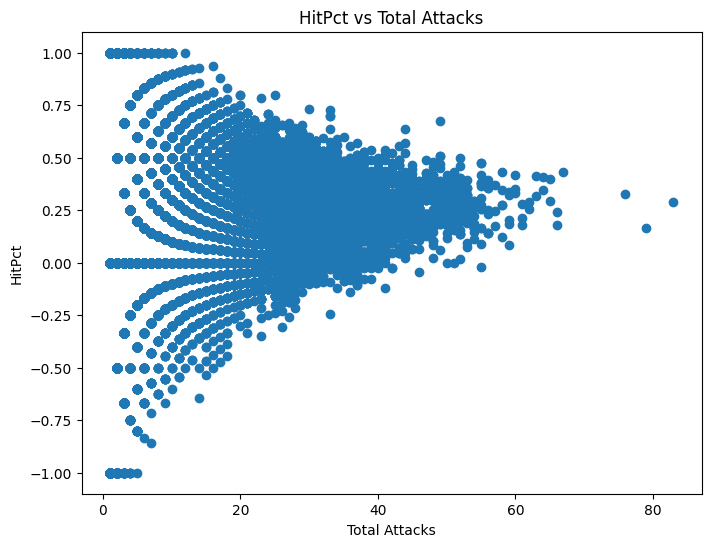

In [91]:
plt.figure(figsize=(8,6))
plt.scatter(analysis_df["TotalAttacks"], analysis_df["HitPct"])
plt.xlabel("Total Attacks")
plt.ylabel("HitPct")
plt.title("HitPct vs Total Attacks")
plt.show()

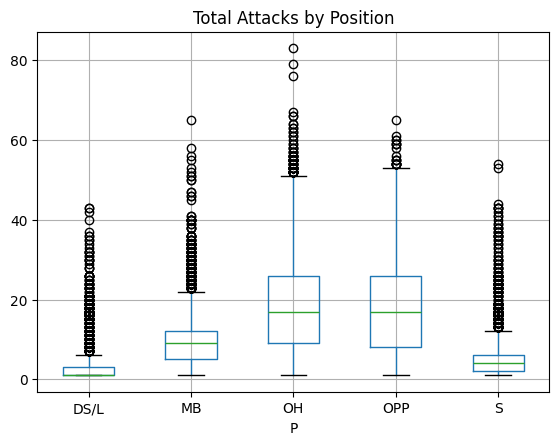

In [92]:
analysis_df.boxplot(column="TotalAttacks", by="P")
plt.title("Total Attacks by Position")
plt.suptitle("")
plt.show()

#### Section 2 of EDA Work load Exploration of Fatigue

The goal is to statistically represent the fatigue decay within the players across sets

In [93]:
#pulling processed data 
data_dir = 'data/02-processed/'
df_mvb_playermatch = pd.read_csv(data_dir + 'mvb_playermatch_combined.csv')
df_mvb_pbp = pd.read_csv(data_dir + 'mvb_pbp_combined.csv')

In [94]:
# Developing a theoretical work load

# Offensive load
df_mvb_playermatch['Jump_Load'] = df_mvb_playermatch['TotalAttacks'] + df_mvb_playermatch['BlockSolos'] + df_mvb_playermatch['Assists']

# Defensive Load
df_mvb_playermatch['Floor_Load'] = df_mvb_playermatch['Digs'] + df_mvb_playermatch['BlockAssists']

#Total possible theoretical load (effort and or actions that in theory require energy)
df_mvb_playermatch['Total_Action_Load'] = df_mvb_playermatch['Jump_Load'] + df_mvb_playermatch['Floor_Load']

#SErr - Service Error occurs when a playery does not have a legal rally (hits net, out of bounds, Foot fault, server takes too long)
#RErr - Reception Error player who was reponsible to pass a serve but failed to do so legally (serve hits floor, out of bounds, shanks)
#BErr - Block error a player (player touches net, centerline violation, over the net, back-row blocker)
#BHE - Ball handling Error foul on touching the ball (double contact, lift/carry)
df_mvb_playermatch['Unforced_Errors'] = df_mvb_playermatch['Errors'] + df_mvb_playermatch['SErr'] + df_mvb_playermatch['RErr'] + df_mvb_playermatch['BErr'] + df_mvb_playermatch['BHE']

#attempted movement that is registered does not account for hidden movements
df_mvb_playermatch['Attacks_Per_Set'] = df_mvb_playermatch['TotalAttacks'] / df_mvb_playermatch['S']

In [95]:
#determine the number of positions

print(f"Dataset Shape: {df_mvb_playermatch.shape}")
print("\nPlayer Count by Position:")
print(df_mvb_playermatch['P'].value_counts(dropna=False))

Dataset Shape: (37570, 31)

Player Count by Position:
P
OH      13927
MB       8184
S        5751
L        4741
OPP      3236
L/DS      998
DB        520
RS        128
MH         85
Name: count, dtype: int64


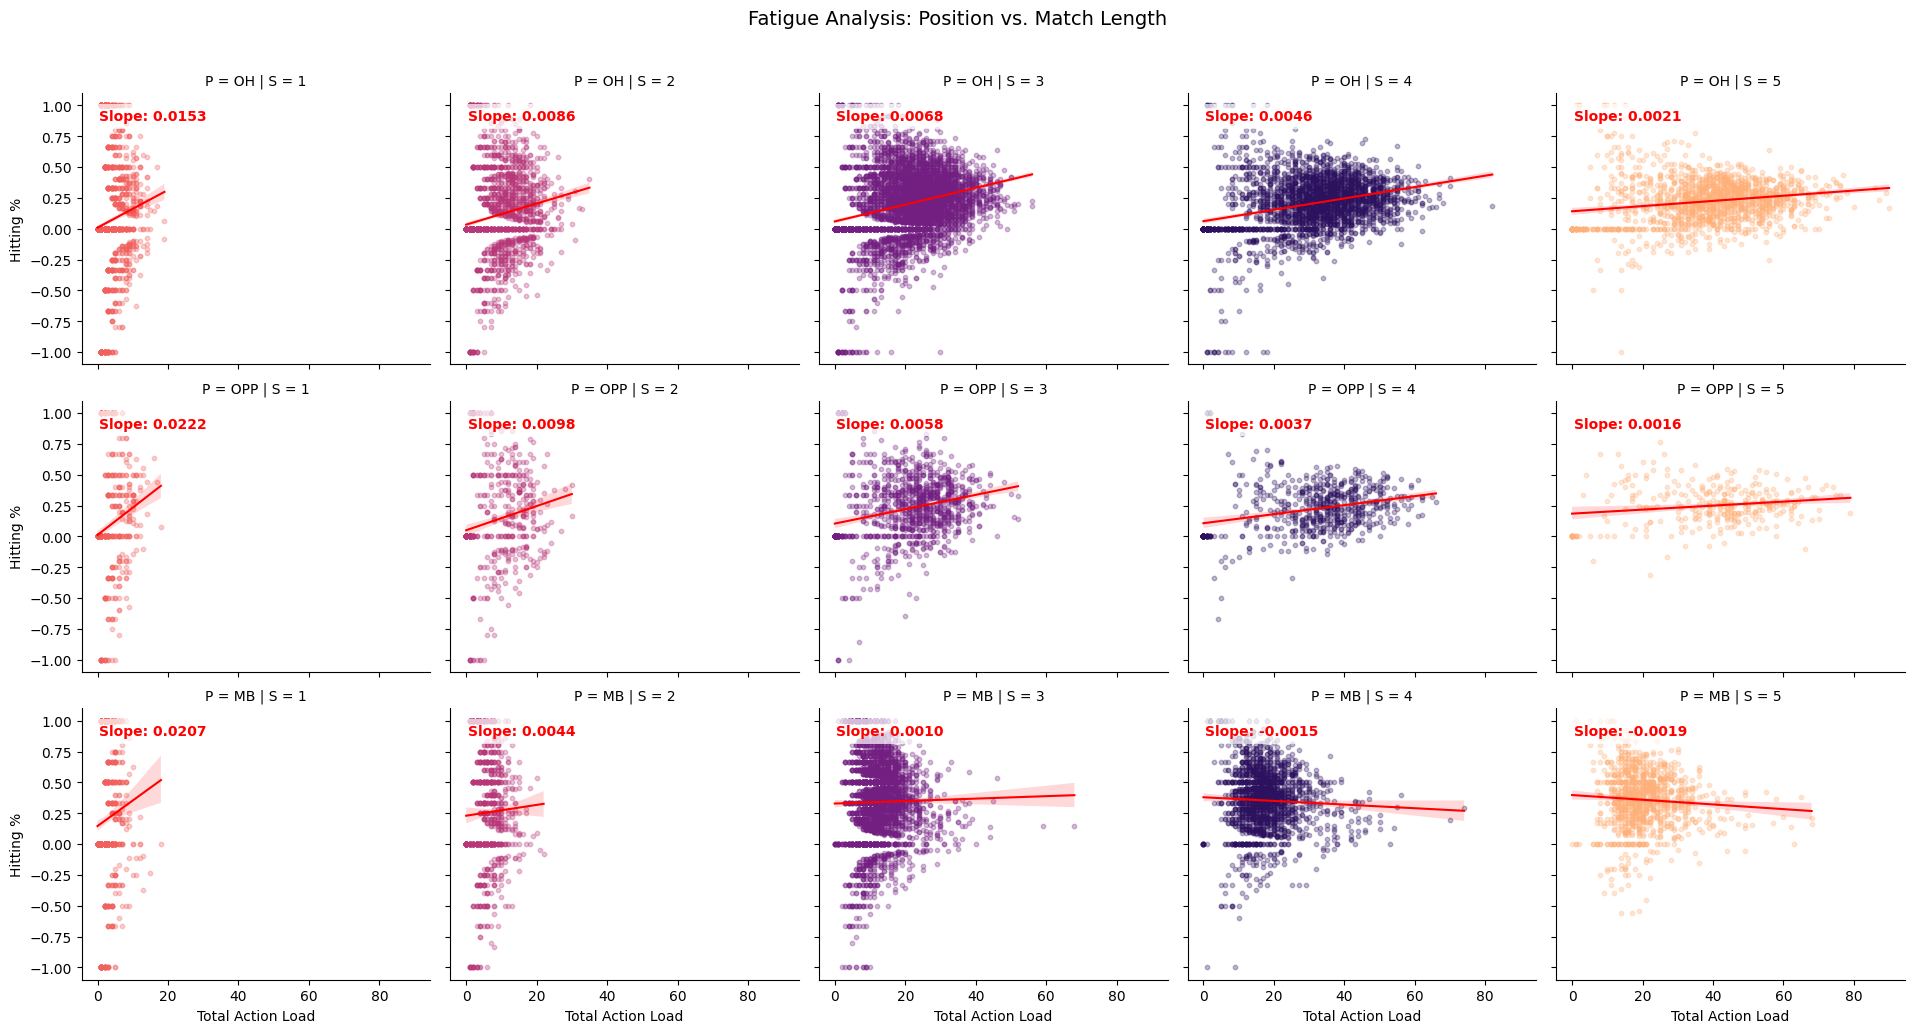

In [96]:
#add positions to demonstrate fatigue
positions = ['OH', 'OPP', 'MB']
set_order = ['1', '2', '3', '4', '5']

grid_df = df_mvb_playermatch[
    (df_mvb_playermatch['P'].isin(positions)) & 
    (df_mvb_playermatch['S'] > 0) 
    #TODO account for staring match player
    # & (df_mvb_playermatch['MS'] == 1) # only use players that are from start enter Need to figure how to implement properly
][['Total_Action_Load', 'HitPct', 'S', 'P']].copy()

grid_df['S'] = grid_df['S'].astype(int).astype(str)

def annotate_slope(data, **kws):
    slope, _, _, _, _ = stats.linregress(data[kws['x']], data[kws['y']])
    
    ax = plt.gca()
    ax.text(0.05, 0.9, f'Slope: {slope:.4f}', 
            transform=ax.transAxes, 
            color='red', 
            fontsize=10, 
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

g = sns.lmplot(
    data=grid_df,
    x='Total_Action_Load',
    y='HitPct',
    hue='S',
    col='S',
    row='P',
    col_order=set_order,
    row_order=positions,
    palette='magma',
    robust=False,  #note takes a long time for now just turn off it elimnates outliers
    scatter_kws={'alpha': 0.3, 's': 10},
    line_kws={'color': 'red', 'linewidth': 1.5},
    height=3.5,
    aspect=1.1
)

# slope annotation
g.map_dataframe(annotate_slope, x='Total_Action_Load', y='HitPct')

g.set_axis_labels("Total Action Load", "Hitting %")
plt.subplots_adjust(top=0.9)
g.figure.suptitle('Fatigue Analysis: Position vs. Match Length', fontsize=14)
plt.show()

#you can see the slope decreasing as the fatigue sets in with each set
#we are going to isolate this behavior as much as possible

In this graph, fatigue analysis is showcased between positions, OH, OPP, and MB, and their hitting percentages across sets. Total action load is defined as the total number of hitting attempts. As shown above, positive slopes for all positions are present in the first two sets, while in the later sets, slopes, over all positions, begin to plateau, emphasizing a decrease in hitting percentage over time. MB's during the 4th and 5th set have negative slopes.

In [97]:
#we are now going to consider play by play data to determine sets more accurately in terms of fatigue

#TODO pbp analysis using the data obtained?

## Ethics

Ethics
Instructions: Keep the contents of this cell. For each item on the checklist


A. Data Collection
 A.1 Informed consent: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent? This project uses pubicly available, aggregated sports perfomce data collected by professional leagues such as the NCAA and VNL. No direct interaction with human subjects occur and no private information is collected. Therefore, for this project and athletes informed consent is not applicable.

 A.2 Collection bias: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those? We are ware that performance data may reflect collection bias due to players having unequal playing time and possible differences in each position played. Therefore one mitigation strategy that may be employed is selectively looking at data per position before combining the data as a whole.
 
 A.3 Limit PII exposure: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis? Our group believes that this item is not relevent for the project.
 A.4 Downstream bias mitigation: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)? This project is intended as an exploratory analysis of player performace statistics. It is not an evaluation of players overall ability, effort, or competence. Conclusions will be statiscal associations rather than judgments about player importance/quality.
B. Data Storage
 
 B.1 Data security: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)? Data is public, so therefore this is not an issue for this project.

 B.2 Right to be forgotten: Do we have a mechanism through which an individual can request their personal information be removed? Our group believes that this item is not relevent for the project.
 
 B.3 Data retention plan: Is there a schedule or plan to delete the data after it is no longer needed? Our group believes that this item is not relevent for the project as the data is publicly available to anyone.
C. Analysis
 
 C.1 Missing perspectives: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)? Quantitative performance metrics may not fully capture other factors such as coaching decisions, injuries, or even pyschological fatigue in players. These limitations will be acknowledged when interpreting results. In addition to acknowledging contextual factors such as injuries and coaching decisions, we recognize that our findings could influence how coaches interpret player fatgiue and game effiiency. For example, if higher cumulative workload is associated with reduced hitting effiency(e.g outside hitter), coaches may use this information to justify limiting playing time or subsituting certain players more often. Quantitative metrics alone may not capture strategic role differences, opponent defensive schemes, or set quality. We therefore acknowledge that statistical trends should not be interpreted without considering tactical context, match tempo, or the specific responsibilities of each position.
 
 C.2 Dataset bias: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)? Quantitative data is taken from a league in which all players are observed, therefore we believe their is little bias in these numbers. However, players with more playing time may dominate the statistics and over-represent in the performance categories. High workload positions such as outside hitter naturally accumulate more attempts and may therefore show larger efficiency fluctuations. Without contextual adjustment, these players could appear less efficient in late set moments, because due to the nature of the sport. Outside hitters carry a greater offensive burden. This creates a risk of role-based bias in intepretations. We may mitigate this by analyzing data within positions where appropriate and clearly stating that efficiency differences may reflect workload distribution rather than individual shortcomings.
 
 C.3 Honest representation: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data? Visualizations and summary statistics will be designed to accurately reflect the data without exaggeration. We will avoid misleading scales, cherry-picking results, or overstating statistical significance. Because findings could influence coaching and player dynamics, any association between workload and efficiency will be framed as statisical pattern. We will avoid ranking players in a way that could unfairly label them as "clutch" or inefficient. 
 
 C.4 Privacy in analysis: Have we ensured that data with PII are not used or displayed unless necessary for the analysis? Our group believes that this item is not relevent for the project.
 
 C.5 Auditability: Is the process of generating the analysis well documented and reproducible if we discover issues in the future? Future analysis will be based on future data provided by the selected volleyball leagues and will be reproducible.
D. Modeling
 
 D.1 Proxy discrimination: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory? The model does not include variables that act as proxies for protected characteristics such as race, gender, or socioeconomic status. Only performance-related variables are used.
 
 D.2 Fairness across groups: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)? We will determine whether model performances is impacted across subgroups such as player positions. In addition to testing subgroup performance across positions, we recognize that model outputs could disproportionately affect players in high-volume roles. If the model predicts reduced efficiency under heavy workload, coaches might adjust substitutions in ways that affect athlete development, confidence, or long-term playing opportunities. We will therefore look at subgroup findings cautiously and avoid framing results in a way that disadvantages specific roles without contextual explanation.
 
 D.3 Metric selection: Have we considered the effects of optimizing for our defined metrics and considered additional metrics? Yes, our group has chosen metrics that we believe strongly relate to player fatigue, such as cumulative in-game actions and performance measures across sets. These metrics are appropriate for addressing our research question. We acknowledge that additional variables, such as player age or injury status, could further contextualize fatigue but are not included due to data availability and scope. This limitation will be noted when interpreting results. While our selected metrics focus on cumulative workload and performance efficiency, we acknowledge that optimizing for efficiency alone could unintentionally undervalue players whose roles require high-risk or high-volume actions. Outside Hitters may take more difficult swings against double blocks, which could lower raw efficiency metrics despite high tactical importance
 
 D.4 Explainability: Can we explain in understandable terms a decision the model made in cases where a justification is needed? If modeling suggests that workload predicts performance decline, we must be able to clearly explain how variables such as cumulative attempts, set progression, and positional role contribute to that conclusion. Transparent explanation is important to prevent misinterpretation by coaches, analysts, and others who may otherwise oversimplify results and apply them in ways that could negatively affect athlete evaluation.
 
 D.5 Communicate limitations: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood? We will clearly communicate that our findings are based on observational player performance metrics and are intended to identify statistical patterns related to fatigue rather than establish causation. Limitations such as unobserved factors will be explicitly stated. Results will be framed as exploratory and contextual rather than definitive evaluations of player ability or performance. Because findings could influence real-world coaching strategies, roster decisions, or athlete workload management, we will explicitly communicate that results are observational and do not establish causation.
E. Deployment
 
 E.1 Monitoring and evaluation: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift) Our group believes that this item is not relevent for the project.
 
 E.2 Redress: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)? Our group believes that this item is not relevent for the project.

 E.3 Roll back: Is there a way to turn off or roll back the model in production if necessary? Our group believes that this item is not relevant for the project.

 E.4 Unintended use: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed? We acknowledge that this project is exploratory and not formally deployed. Findings could be applied in ways that negatively impact athlete development, such as prematurely limiting playing time and labeling athletes as inefficient or not "clutch". Coaches could use these findings to change roster dynamics without remembering contextual analysis.We therefore emphasize that results should be used as supportive insights rather than definitive evaluations, and any practical application should incorporate coaching expertise, athlete communication, and broader sports science considerations. 


## Team Expectations 

*Group Names* : Joseph Tuazon, Ivan Li, Alexis Menor, Camdon Dreisbach, Yuna Yeom 

* *Team Expectation 1* : Communicate well over discord and try to respond to messages as soon a possible. Regarding to meetings we will try and meet once a weel but understanding that people have other things in their lives it is okay.
* *Team Expectation 2* : Be nice to eachother in the groups. When disagreeing with an idea explain why but also understand the other person's point of view.
* *Team Expecation 3* : When making decisions listen other other people's proposal and provide feedback if possible.
* *Team Expecation 4* : Try and complete the task assigned before the certain due date 

## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/3  |  7 PM | Think about the project proposal and ideas for the actual project  | Talked about the project idea and split up the work assignment that is due on Wednesday | 
| 2/10  |  7 PM |  Do background research on topic | TBA | 
| 2/17  |  7 PM  | Look over the data sets/find special features about that data set that can help with our project  | Detailed work load for each group member to accomplish what we need to work on and how we can improve lack criteria. |
| 2/24 | 7 PM  | Import the data into the code and clean it up (getting rid of useless data) | TBA |
| 3/3 | 7 PM  | Beginning the analysis of the data and writing down specifics about the research | TBA |
| 3/10  | 7 PM  | Complete analysis; Draft results/conclusion/discussion (Wasp)| TBA|
| 3/17 | 7 PM  | TBA | TBA |